# Image Classification

## Import

In [2]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import ToTensor,Compose,RandomHorizontalFlip, Normalize, ToPILImage, RandomRotation, ColorJitter
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import torchvision
import torch.optim.lr_scheduler as lr_scheduler

from tools.plot import show_images, plot_metrics, plot_cifar_distribution


## datasets

### Official Implementation 

In [ ]:
# dataset config
batch_size = 128

# 定义了一个三通道RGB图像预处理的转换管道，先将图像转换为张量，然后对图像进行均值和标准差均为 (0.5, 0.5, 0.5)的归一化处理
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
# TODO:
# 使用 PyTorch 的 torchvision.datasets.CIFAR10 加载训练集和测试集。
# Hint: 可以参考https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
trainset = 
testset = 

In [ ]:
# TODO:
# 使用 DataLoader 创建训练和测试数据加载器，支持批量处理和数据打乱。
trainloader =
testloader = 

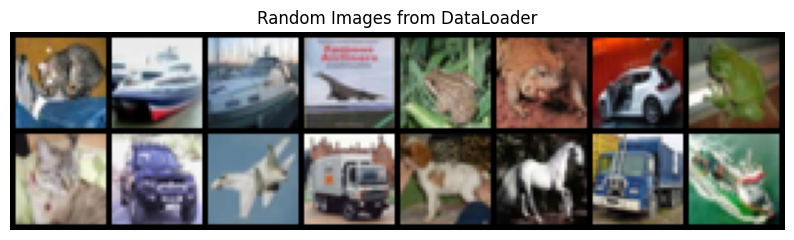

Labels: cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship 


In [ ]:

# show some images from dataset
show_images(testloader, classes=classes, num_images=16)

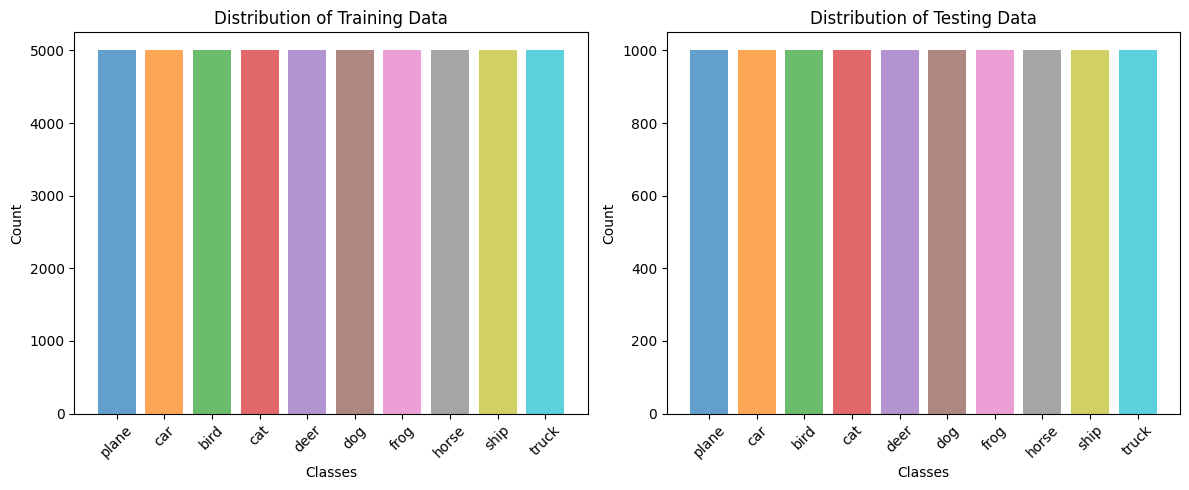

In [3]:
# 绘制分布图
plot_cifar_distribution(trainset, testset, classes)

## Define a Linear Neural Network

In [ ]:
# 请前往models/linear_model.py实现线性模型，并在此处创建一个实例
from models.linear_model import LinearModel

## Define a Multilayer Perceptron Model

In [ ]:
# 请前往models/mlp.py实现MLP模型，并在此处创建一个实例
# from models.mlp import MLP

## Training Loop

In [ ]:
# 训练一个batch的函数
def train_one_batch(model, inputs, labels, optimizer, criterion, device):
    """
    Args:
        model (nn.Module): 神经网络模型
        inputs (torch.Tensor): 输入数据，形状为 (batch_size, channels, height, width)
        labels (torch.Tensor): 真实标签，形状为 (batch_size,)
        optimizer (torch.optim.Optimizer): 优化器（如 torch.optim.SGD）
        criterion (nn.Module): 损失函数（如 nn.CrossEntropyLoss）
        device (torch.device): 运行设备（'cpu' 或 'cuda'）
    
    Returns:
        tuple: (loss, outputs)
            - loss (torch.Tensor): 当前批次的损失值（标量）
            - outputs (torch.Tensor): 模型的输出，形状为 (batch_size, num_classes)
    """
    # TODO: 实现函数
    # 1. 将inputs和labels移动到指定设备device
    inputs, labels = 

    # 2. 重置优化器optimizer的梯度


    # 3. 前向传播：通过模型model计算输出
    outputs = 

    # 4. 计算损失loss
    loss = 

    # 5. 反向传播：计算梯度


    # 6. 更新参数

    
    return loss, outputs



# Evaluation

In [ ]:
# 测试函数，用于评估模型在测试集上的性能
def evaluate(model, test_loader, criterion, device):
    # 将模型设置为评估模式（禁用 dropout 和 batch normalization 等训练时的特性）
    model.eval()
    
    # 初始化变量，用于累计总损失、正确预测数和样本总数
    total_loss = 0      # 累计所有批次的损失
    total_correct = 0   # 累计正确预测的样本数
    total_samples = 0   # 累计总样本数
    
    # 使用 torch.no_grad() 禁用梯度计算以节省内存和提高速度
    with torch.no_grad():
        # 遍历测试数据加载器中的每个批次
        for inputs, labels in test_loader:
            # 将输入数据和标签移动到指定的设备（CPU 或 GPU），其中labels 是一个包含类别索引的张量
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 前向传播：通过模型获取预测输出
            outputs = model(inputs)
            
            # 计算当前批次的损失
            loss = criterion(outputs, labels)
            
            # 累计总损失（loss.item() 获取标量值）
            total_loss += loss.item()
            
            # 获取预测结果：torch.max 返回每一行的最大值及其索引，索引赋值给predicted，1 表示每行在列维度上求最大值
            _, predicted = torch.max(outputs.data, 1)
            
            # 统计当前批次的样本数（labels.size(0) 是批次大小）
            total_samples += labels.size(0)
            
            # 统计正确预测的样本数
            # (predicted == labels) 返回布尔张量，sum() 计算 True 的总数，item() 转为标量
            total_correct += (predicted == labels).sum().item()
    
    # 计算平均损失：总损失除以批次数量
    avg_loss = total_loss / len(test_loader)
    
    # 计算准确率：正确预测数除以总样本数
    accuracy = total_correct / total_samples
    
    # 返回平均损失和准确率
    return avg_loss, accuracy

In [ ]:
# 超参数
num_epochs = 20
learning_rate = 0.001

# TODO: 设备选择
# 1. 检查是否有可用的 GPU (torch.cuda.is_available())
# 2. 如果有 GPU，使用 "cuda"；否则使用 "cpu"
# 3. 将结果赋值给 device (类型为 torch.device)
device = 

In [ ]:
# TODO: 初始化模型
# 1. 创建 LinearModel 的实例
# 2. 将模型移动到上面定义的 device 上
model =

In [ ]:
# TODO: 初始化损失函数
# 1. 使用 nn.CrossEntropyLoss 定义交叉熵损失
criterion = 

In [ ]:

# TODO: 初始化优化器
# 1. 使用 torch.optim.Adam 创建优化器
# 2. 传入模型参数 (model.parameters()) 和学习率 (learning_rate)
optimizer = 

In [ ]:
# TODO: 配置学习率调度器
# 使用 lr_scheduler.StepLR，设置每 5 个 epoch 学习率减半（gamma=0.5）
scheduler = 

## Main Loop

In [ ]:
# 记录训练过程中的指标
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
learning_rates = []
# 训练循环
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_correct = 0
    total_samples = 0
    
    # 按batch训练
    for i, batch_data in enumerate(trainloader):
        inputs, labels = batch_data
        inputs, labels = inputs.to(device), labels.to(device)
        batch_loss, batch_output = train_one_batch(model, inputs, labels, optimizer, criterion, device)
        epoch_loss += batch_loss.item()

        # TODO: 计算当前 batch 的预测和准确率
        # 1. 从 batch_output 中获取预测类别 (使用 torch.max)
        # 2. 获取当前批次大小 (labels 的第 0 维大小)
        # 3. 更新 total_samples (累加批次大小)
        # 4. 计算正确预测的数量并更新 epoch_correct
        
        batch_prediction = 
        batch_size = 
        total_samples =
        epoch_correct =
            
    # 计算epoch los
    avg_train_loss = epoch_loss / len(trainloader)
    
    # TODO: 计算 epoch 平均准确率
    # 使用 epoch_correct 和 total_samples 计算平均准确率
    avg_train_acc = 
    
    # 测试
    test_loss, test_acc = evaluate(model, testloader, criterion, device)
    
    # 记录指标
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    learning_rates.append(scheduler.get_last_lr()[0])  # 记录当前学习率

    # 每个 epoch 结束后使用scheduler更新学习率
    scheduler.step()
    
    # 打印训练状态
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    print(f'Current Learning Rate: {scheduler.get_last_lr()[0]:.6f}')  # 打印当前学习率


Epoch [1/20]
Train Loss: 1.8386, Train Acc: 0.3629
Test Loss: 1.8099, Test Acc: 0.3629
Current Learning Rate: 0.001000
Epoch [2/20]
Train Loss: 1.7662, Train Acc: 0.3932
Test Loss: 1.7988, Test Acc: 0.3766
Current Learning Rate: 0.001000
Epoch [3/20]
Train Loss: 1.7449, Train Acc: 0.4032
Test Loss: 1.7600, Test Acc: 0.3950
Current Learning Rate: 0.001000
Epoch [4/20]
Train Loss: 1.7297, Train Acc: 0.4071
Test Loss: 1.7631, Test Acc: 0.3809
Current Learning Rate: 0.001000
Epoch [5/20]
Train Loss: 1.7177, Train Acc: 0.4123
Test Loss: 1.7782, Test Acc: 0.3892
Current Learning Rate: 0.000500
Epoch [6/20]
Train Loss: 1.6715, Train Acc: 0.4309
Test Loss: 1.7332, Test Acc: 0.4029
Current Learning Rate: 0.000500
Epoch [7/20]
Train Loss: 1.6642, Train Acc: 0.4307
Test Loss: 1.7407, Test Acc: 0.4008
Current Learning Rate: 0.000500
Epoch [8/20]
Train Loss: 1.6629, Train Acc: 0.4338
Test Loss: 1.7412, Test Acc: 0.4000
Current Learning Rate: 0.000500
Epoch [9/20]
Train Loss: 1.6593, Train Acc: 0.43

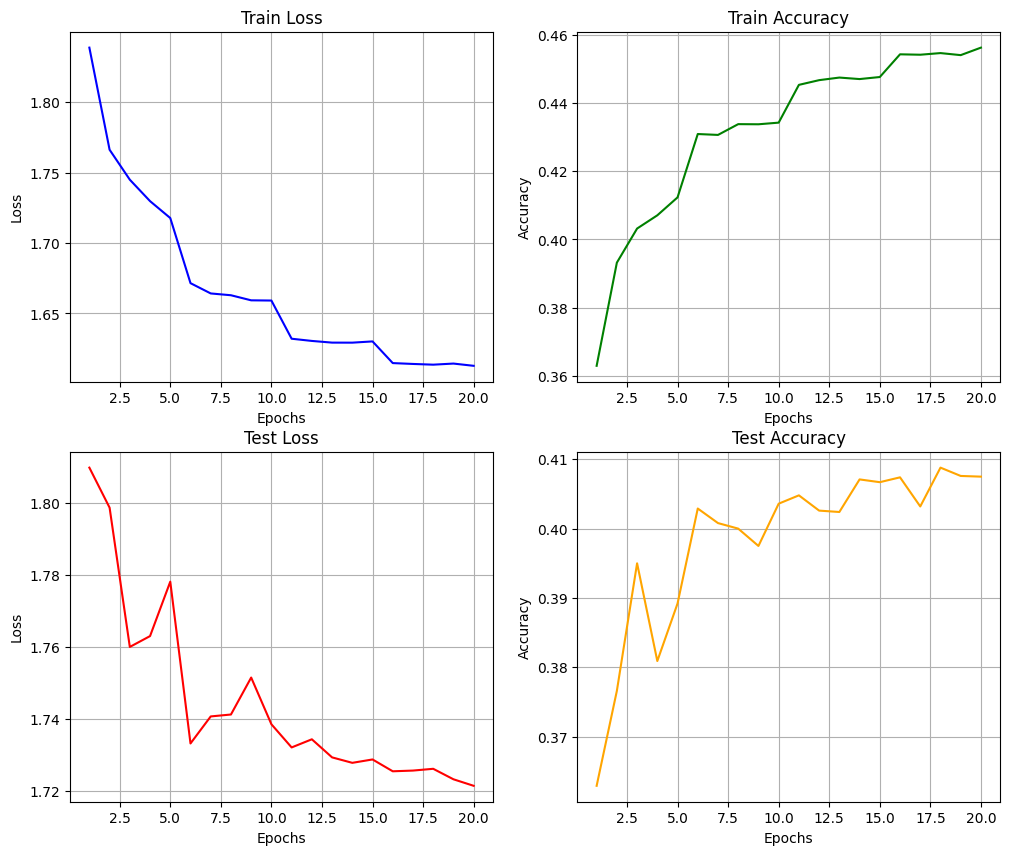

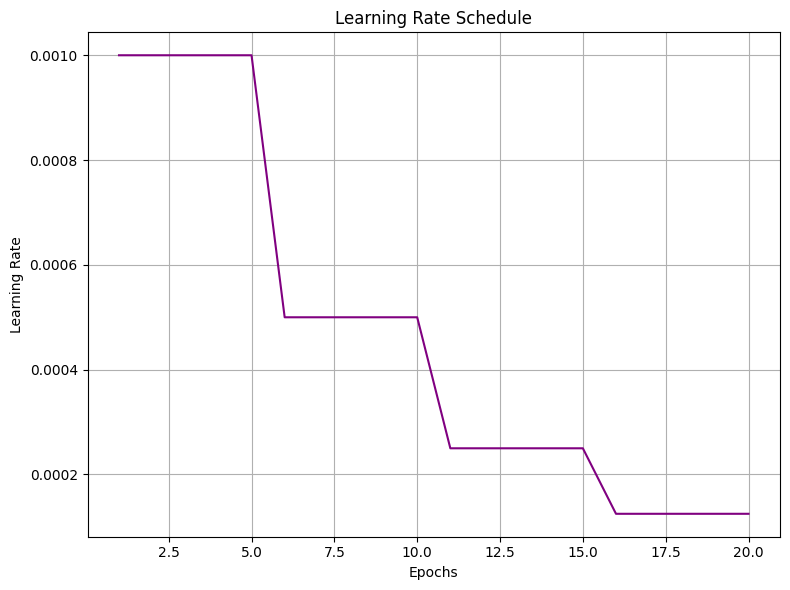

In [9]:
plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies, learning_rates, num_epochs)

## Exercise

### Objective

1. 尝试修改 MLP的激活函数，将 ReLU 替换为 Tanh，并比较不同激活函数对模型性能的影响，包括训练收敛速度和最终测试准确率等方面
- Hint:可以参考PyTorch官方链接：[Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html#torch.nn.Tanh)
2. (Optional)调整MLP的层数并观察模型准确率变化
3. (Optional)在exercise.ipynb实现SoftMax，Cross Entropy Loss

